# Correcting WCS Position of Aligned TolTEC Image

In [1]:
# load packages
%matplotlib inline
%config InlineBackend.figure_format='retina'
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from photutils.centroids import centroid_com
from offset_functions import absolute_pointing_offset

In [2]:
redu_num = '61' # Reduction number of the aligned coadded image
wav = '1100' # Desired wavelength in microns
fov = 5 # FOV of observation in arcseconds (5 for 1100, 6.3 for 1400, and 9.5 for 2000)
crop = 150 # How much of the edge to crop out, necessary due to artifacts
y_push, x_push = 0, 0 # Optional x-y shifts added to the center of the viewed image
n_iter = 1000 # Amount of tested centroids

Location of Image (Dec, RA) (Degrees): (-24.39917, 246.6146)


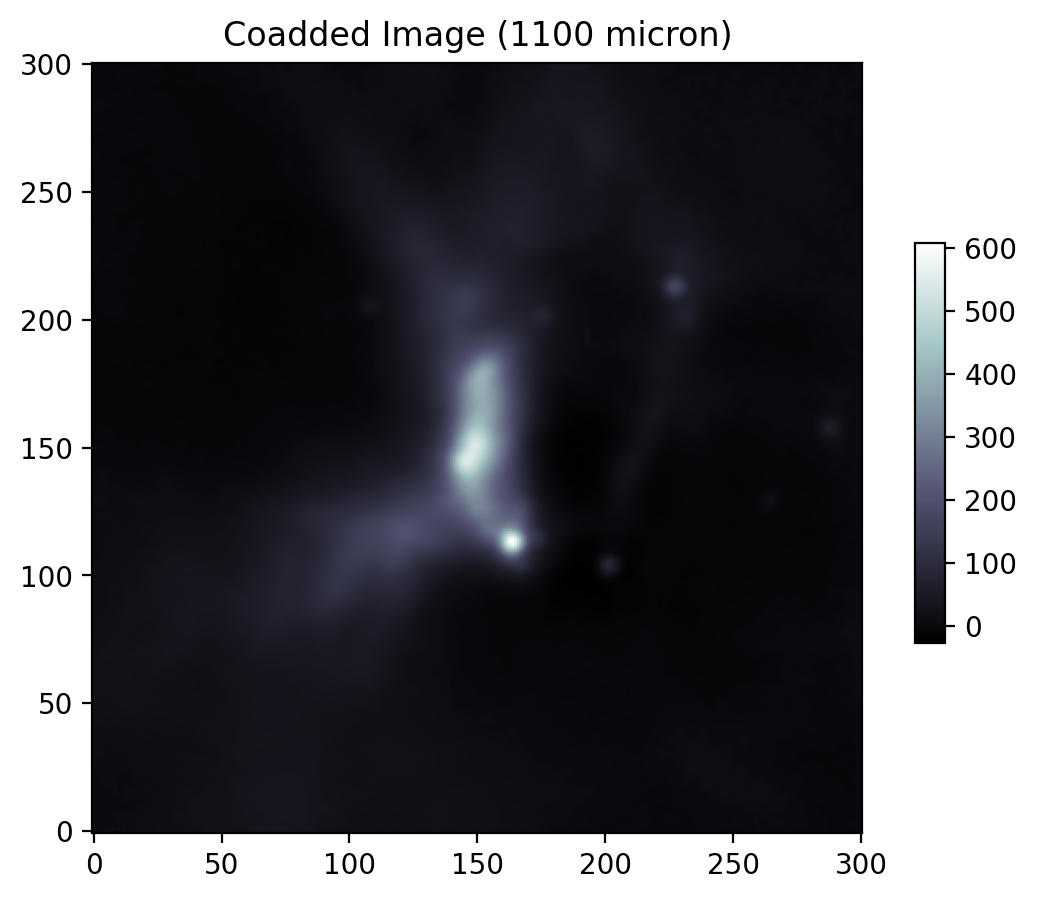

In [3]:
# Obtains the coadded image (data) and its information (header)
data, header = fits.getdata('./redu' + redu_num + '/coadded/raw/toltec_commissioning_a' + wav + '_citlali.fits', ext=1, header=True)

# Finds the center pixel of the image
coadd_center = (int(header['CRPIX2']), int(header['CRPIX1']))
# Finds the RA/DEC WCS location of the center pixel
ref_dec, ref_ra = header['CRVAL2']*3600, header['CRVAL1']*3600
print(f'Location of Image (Dec, RA) (Degrees): {(ref_dec/3600, ref_ra/3600)}')

# Crops the image as specified above
coadd_y_min, coadd_y_max = coadd_center[0]-crop-1+y_push, coadd_center[0]+crop+y_push
coadd_x_min, coadd_x_max = coadd_center[1]-crop-1+x_push, coadd_center[1]+crop+x_push
offset_coadd_img = data[0][0][coadd_y_min:coadd_y_max, coadd_x_min:coadd_x_max]

# Plots the image
fig, ax = plt.subplots(1, 1)
fig.set_figheight(5)
fig.set_figwidth(5)
im = ax.imshow(offset_coadd_img, cmap='bone', origin='lower')
ax.set_title(f'Coadded Image ({wav} micron)')
fig.colorbar(im, ax=ax, cax=fig.add_axes([0.95, 0.3, 0.03, 0.4]));

In [4]:
# Accurate RA/DEC WCS position of VLA 1623-243 as queried from Simbad
source_dec = -24.40833
source_ra = 246.61008
# Guess for the (y, x) pixel center of a point source in offset_coadd_img, in this case VLA 1623-243
source_center_guess = (113, 164)
img_width = 50 # Pixel width of image centered on point source

Guessed Point Source Center (Pixels): (264, 315)
Final Itervative Point Source Centroid (Pixels): (264.6588773029096, 314.60878154319516)
Position Relative to Center Pixel (Pixels): (-26.341122697090384, 7.608781543195164)
Guessed Location of Chosen Source (Dec, RA) (Degrees): (-24.40648697852697, 246.61671355042864)
Absolute Offset (Dec, RA) (Arcseconds): (-6.634877302902169, -23.88078154309187)


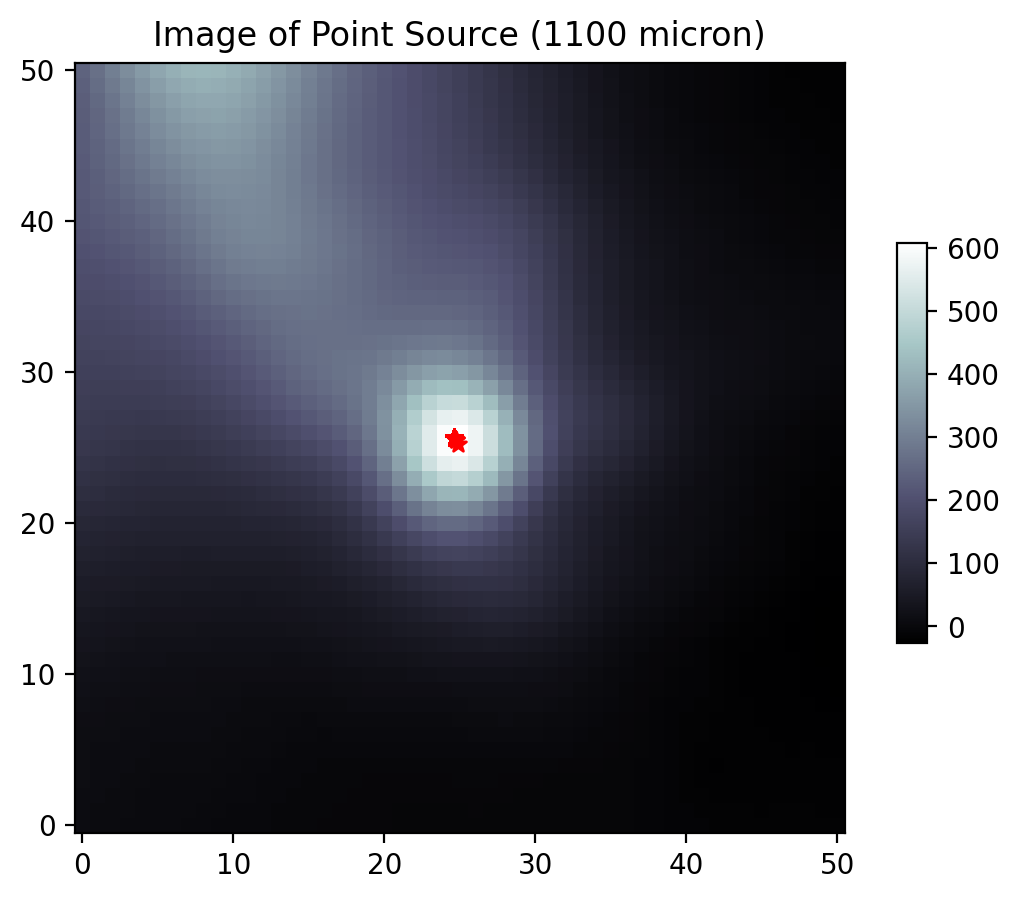

In [5]:
# Look at offset_functions.py for more info on absolute_pointing_offset
absolute_offset = absolute_pointing_offset(offset_coadd_img, coadd_center, ref_dec, ref_ra, source_center_guess, 
                                           source_dec, source_ra, img_width, fov, wav, crop, n_iter, x_push, y_push)

In [6]:
# Updates location values in the file header to account for the discovered offset
header['CRVAL1'] = header['CRVAL1'] + float(absolute_offset[0])/3600
header['CRVAL2'] = header['CRVAL2'] + float(absolute_offset[1])/3600
print(f'Adjusted Location of Image (Dec, RA) (Degrees): {(header["CRVAL2"], header["CRVAL1"])}')

Adjusted Location of Image (Dec, RA) (Degrees): (-24.40101302147303, 246.60796644957136)


In [7]:
# Writes the position-corrected file into the same folder, with the addition of '_centered' to differentiate it from the previous file
fits.writeto('./redu' + redu_num + '/coadded/raw/toltec_commissioning_a' + wav + '_citlali_centered.fits', data, header, overwrite=True)